# **DATA UNDERSTANDING**

1. Load semua dataset

2. Cek struktur & ukuran data

3. Cek missing values

4. Cek duplicate

5. Audit tipe data

6. Memahami relasi tabel

## **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 5)

## **Load Dataset**

In [ ]:
customers = pd.read_csv('customers_dataset.csv')
orders = pd.read_csv('orders_dataset.csv')
order_items = pd.read_csv('order_items_dataset.csv')
order_payments = pd.read_csv('order_payments_dataset.csv')
order_reviews = pd.read_csv('order_reviews_dataset.csv')
products = pd.read_csv('products_dataset.csv')
sellers = pd.read_csv('sellers_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')
geolocation = pd.read_csv('geolocation_dataset.csv')

## **Cek Ukuran Dataset**

In [ ]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation,
    "geolocation": geolocation
}

for name, df in datasets.items():
    print(f"{name} shape: {df.shape}")

customers shape: (99441, 5)
orders shape: (99441, 8)
order_items shape: (112650, 7)
order_payments shape: (103886, 5)
order_reviews shape: (99224, 7)
products shape: (32951, 9)
sellers shape: (3095, 4)
category_translation shape: (71, 2)
geolocation shape: (1000163, 5)


📌 **Insight Dataset Size**

* Dataset terbesar adalah geolocation (~1 juta rows)

* order_items lebih besar dari orders karena 1 order bisa banyak item

* order_payments lebih besar karena 1 order bisa punya beberapa pembayaran

## **Audit Struktur & Missing Value**

In [ ]:
for name, df in datasets.items():
    print("="*50)
    print(f"Dataset: {name}")
    print(df.info())
    print("\nMissing Values:")
    print(df.isnull().sum())

Dataset: customers
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Dataset: orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id     

📌 **Insight Dataset Size**

* Dataset terbesar adalah geolocation (~1 juta rows)

* order_items lebih besar dari orders karena 1 order bisa banyak item

* order_payments lebih besar karena 1 order bisa punya beberapa pembayaran

## **Cek Duplicate**

In [ ]:
for name, df in datasets.items():
    print(f"{name} duplicates: {df.duplicated().sum()}")

customers duplicates: 0
orders duplicates: 0
order_items duplicates: 0
order_payments duplicates: 0
order_reviews duplicates: 0
products duplicates: 0
sellers duplicates: 0
category_translation duplicates: 0
geolocation duplicates: 261831


📌 **Insight Missing Value**

* Missing delivery date kemungkinan berasal dari order cancelled

* Missing product category sekitar 610 entries

* Missing review message normal (tidak semua customer menulis komentar)

# **MASTER TABLE VALIDATION & REVENUE CONTROL**

1. Convert kolom datetime

2. Filter hanya transaksi valid (delivered)

3. Perbaiki missing value penting

4. Merge tabel dengan benar

5. Buat metrik revenue yang akurat

6. Siapkan dataset untuk analisis tren & RFM

## **Convert Datetime Columns**

In [ ]:
# Convert datetime columns
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

***NB***

"Seluruh kolom bertipe waktu dikonversi ke format datetime untuk memungkinkan analisis time-series dan perhitungan Recency pada RFM analysis."

## **Filter Order Delivered**

In [ ]:
orders = orders[orders['order_status'] == 'delivered']

***NB***

"Analisis difokuskan hanya pada order dengan status "delivered" untuk memastikan revenue yang dihitung benar-benar terealisasi."

## **Handle Missing Category**

In [ ]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')

***NB***

"Missing product category diisi dengan label "unknown" agar tidak hilang saat dilakukan grouping kategori."

## **MERGE**

In [ ]:
# Merge orders + customers
master_df = orders.merge(customers, on='customer_id', how='left')

# Merge order_items
master_df = master_df.merge(order_items, on='order_id', how='left')

# Merge products
master_df = master_df.merge(products, on='product_id', how='left')

# Merge category translation
master_df = master_df.merge(category_translation, on='product_category_name', how='left')

# Merge sellers
master_df = master_df.merge(sellers, on='seller_id', how='left')

# Merge review score
master_df = master_df.merge(order_reviews[['order_id','review_score']],
                            on='order_id', how='left')

## **BUAT METRIK REVENUE**

In [ ]:
master_df['revenue'] = master_df['price'] + master_df['freight_value']

## **FEATURE ENGINEERING TIME**

In [ ]:
master_df['year'] = master_df['order_purchase_timestamp'].dt.year
master_df['month'] = master_df['order_purchase_timestamp'].dt.month
master_df['month_year'] = master_df['order_purchase_timestamp'].dt.to_period('M')

## **VALIDASI MASTER DATASET**

In [ ]:
print("Shape:", master_df.shape)
master_df.head()

Shape: (110840, 35)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,review_score,revenue,year,month,month_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350,maua,SP,4.0,38.71,2017,10,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570,belo horizonte,SP,4.0,141.46,2018,7,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840,guariba,SP,5.0,179.12,2018,8,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,31842,belo horizonte,MG,5.0,72.20,2017,11,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,8752,mogi das cruzes,SP,5.0,28.62,2018,2,2018-02


In [ ]:
master_df.isnull().sum().sort_values(ascending=False).head(15)

,0
product_category_name_english,1567
product_description_lenght,1545
...,...
order_id,0
customer_id,0


In [ ]:
master_df['product_category_name_english'] = master_df['product_category_name_english'].fillna('unknown')

📌 **Insight**

Setelah dilakukan proses merging, jumlah baris meningkat karena satu order dapat terdiri dari beberapa item. Dataset siap digunakan untuk analisis revenue dan segmentasi pelanggan.

# **REVENUE & BUSINESS PERFORMANCE ANALYSIS**

* Hitung total revenue

* Hitung total orders

* Hitung unique customers

* Hitung Average Order Value

* Buat visualisasi tren bulanan

* Identifikasi peak month

* Mulai insight strategis

## **KPI**

In [ ]:
total_revenue = master_df['revenue'].sum()
total_orders = master_df['order_id'].nunique()
total_customers = master_df['customer_unique_id'].nunique()

aov = total_revenue / total_orders

print("Total Revenue: ", round(total_revenue,2))
print("Total Orders: ", total_orders)
print("Total Unique Customers: ", total_customers)
print("Average Order Value (AOV): ", round(aov,2))

Total Revenue:  15489665.55
Total Orders:  96478
Total Unique Customers:  93358
Average Order Value (AOV):  160.55


📌 **Insight KPI**

1. **Total Revenue** = 15.49 Juta
* Dataset cukup representatif

* Bisa dianalisis untuk growth & sustainability

2. **Total Orders vs Unique Customers** (Rasio repeat order sangat kecil.)

* **Repeat rate** ≈
(Orders - Unique Customers) / Unique Customers (96,478 - 93,358) / 93,358
= 3.3%

* Sebagian besar pelanggan hanya melakukan 1 kali pembelian.

**Indikasi**:
* Customer retention rendah

* Peluang besar untuk strategi loyalty & remarketing

* RFM Analysis akan sangat relevan

3. **Average Order Value (AOV)** = 160.55

* Rata-rata nilai transaksi cukup moderat

* Tidak terlalu low-value

* Tidak high-end marketplace

**Ini cocok untuk:**

* Upselling strategy

* Bundling product strategy

## **Monthly Revenue Trend**

In [ ]:
monthly_revenue = master_df.groupby('month_year')['revenue'].sum().reset_index()
monthly_revenue['month_year'] = monthly_revenue['month_year'].astype(str)

monthly_orders = master_df.groupby('month_year')['order_id'].nunique().reset_index()
monthly_orders['month_year'] = monthly_orders['month_year'].astype(str)

## **Visualisasi Revenue Trend**

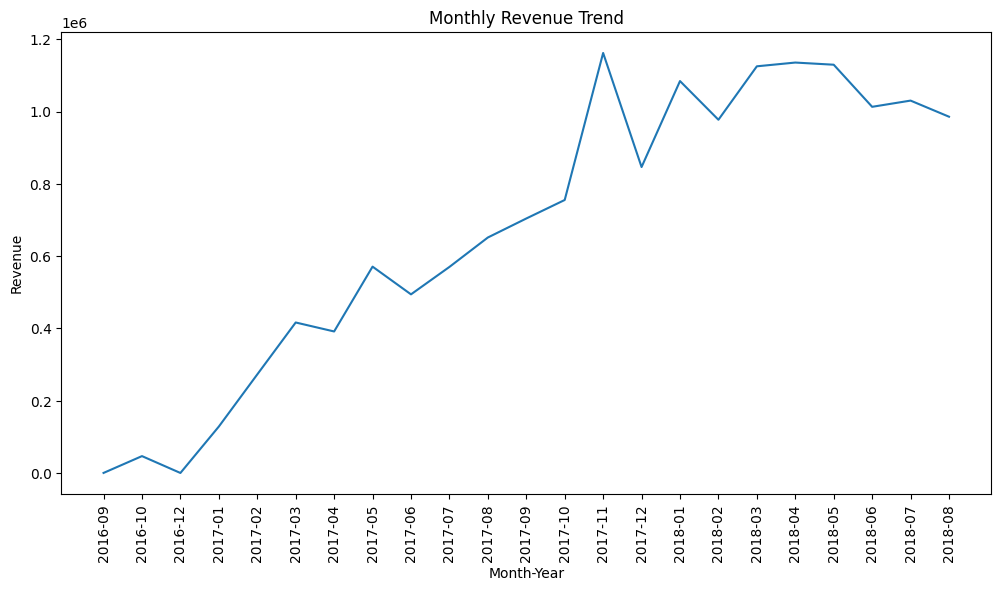

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue['month_year'], monthly_revenue['revenue'])
plt.xticks(rotation=90)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month-Year')
plt.ylabel('Revenue')
plt.show()

📌 **Fase Awal (2016)**

Revenue sangat kecil → **kemungkinan**:

* Platform masih dalam tahap awal

* Data mulai terekam

📌 **2017 → Growth Phase**

Terlihat:

* Growth konsisten dari awal 2017

* Puncak pertama di sekitar November 2017

**Kemungkinan besar:**
Black Friday effect (November spike sangat khas e-commerce)

📌 **2018 → Stabil & High Revenue**

Revenue stabil di kisaran 1 juta per bulan.
**teks tebal**

*Artinya:*

* Bisnis sudah mature

* Tidak lagi fase startup growth

* Revenue plateau

📌 **Peak Month**

Bulan dengan revenue tertinggi terlihat sekitar:

November 2017

Ini tipikal:

* High season retail

* Campaign driven revenue

📌 **Insight**

Revenue menunjukkan pola pertumbuhan signifikan sepanjang 2017 dan mencapai puncak pada November 2017 yang kemungkinan dipengaruhi oleh event promosi besar seperti Black Friday. Pada 2018, revenue relatif stabil di kisaran 1 juta per bulan, menunjukkan bisnis telah memasuki fase maturity dengan pertumbuhan yang lebih stabil.

Tingkat repeat customer relatif rendah (~3%), menunjukkan peluang besar untuk meningkatkan customer retention melalui program loyalty atau remarketing strategy.

## **Visualisasi Order Trend**

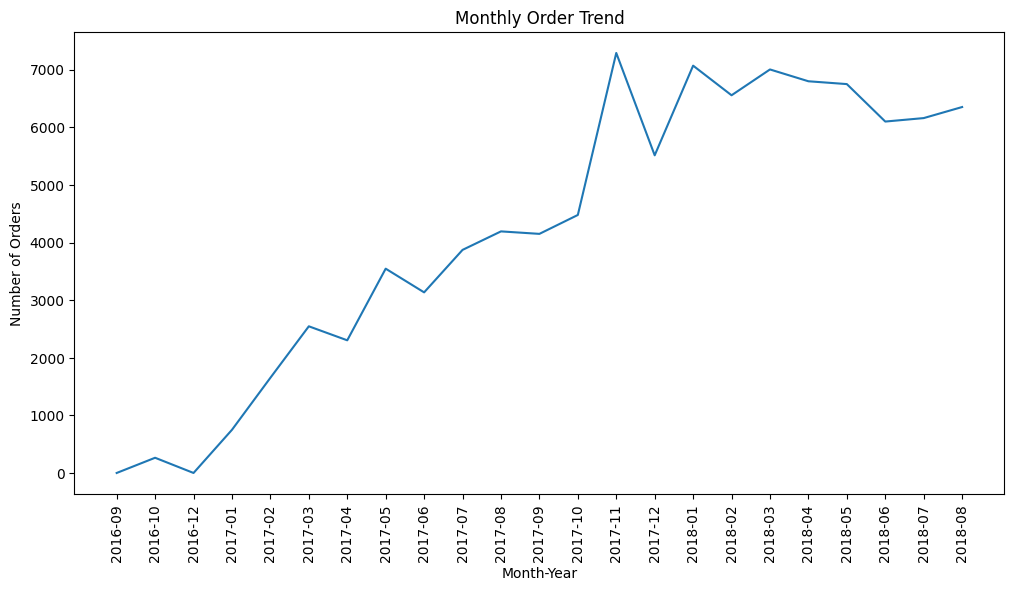

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(monthly_orders['month_year'], monthly_orders['order_id'])
plt.xticks(rotation=90)
plt.title('Monthly Order Trend')
plt.xlabel('Month-Year')
plt.ylabel('Number of Orders')
plt.show()

Dari pola grafik, terlihat:
Revenue & order cenderung naik bersamaan.

Artinya:
Growth berasal dari peningkatan volume transaksi.

📌 **Insight**

Revenue menunjukkan pola pertumbuhan signifikan sepanjang 2017 dan mencapai puncak pada November 2017 yang kemungkinan dipengaruhi oleh event promosi besar seperti Black Friday. Pada 2018, revenue relatif stabil di kisaran 1 juta per bulan, menunjukkan bisnis telah memasuki fase maturity dengan pertumbuhan yang lebih stabil.

Tingkat repeat customer relatif rendah (~3%), menunjukkan peluang besar untuk meningkatkan customer retention melalui program loyalty atau remarketing strategy.

# **RFM CUSTOMER SEGMENTATION**

**Kita akan menghitung:**

* Recency → Seberapa lama sejak terakhir beli

* Frequency → Berapa kali beli

* Monetary → Total belanja

Lalu kita **segmentasi customer** menjadi:

* Champions

* Loyal

* Big Spenders

* At Risk

* New Customers

## **Snapshot Date**

In [ ]:
snapshot_date = master_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2018-08-30 15:00:37')

## **Hitung RFM**

In [ ]:
rfm = master_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'revenue': 'sum'
}).reset_index()

rfm.columns = ['customer_id','Recency','Frequency','Monetary']

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


## **RFM Scoring dengan Quantile**

In [ ]:
# Recency (semakin kecil semakin baik)
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

# Frequency (semakin besar semakin baik)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

# Monetary (semakin besar semakin baik)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4


## **RFM Score Gabungan**

In [ ]:
rfm['RFM_score'] = rfm['R_score'].astype(str) + \
                   rfm['F_score'].astype(str) + \
                   rfm['M_score'].astype(str)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214


## **Segmentasi Customer**

In [ ]:
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

In [ ]:
def segment_customer(row):
    if row['R_score'] == 5 and row['F_score'] >= 4:
        return 'Champions'
    elif row['F_score'] >= 4:
        return 'Loyal Customers'
    elif row['M_score'] == 5:
        return 'Big Spenders'
    elif row['R_score'] <= 2:
        return 'At Risk'
    else:
        return 'Potential'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
Loyal Customers,29808
Potential,27342
At Risk,18108
Big Spenders,10565
Champions,7535


## **Visualisasi Distribusi Segment**

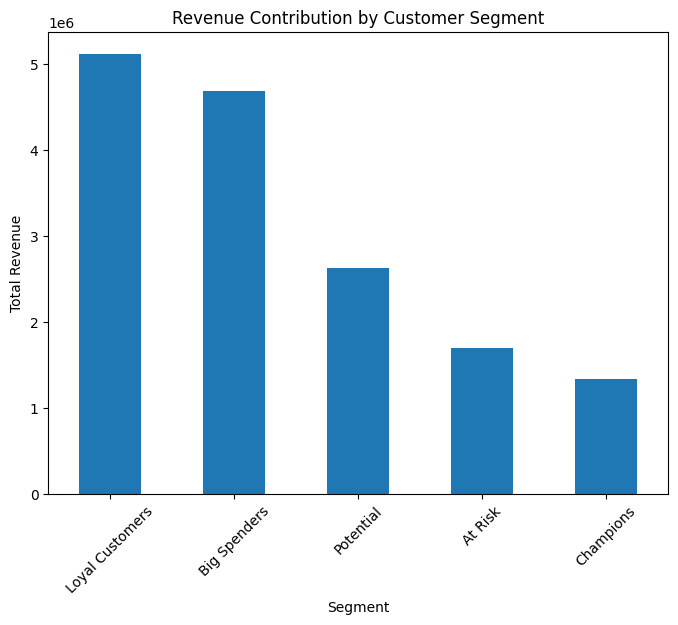

,revenue
Segment,
Loyal Customers,5120524.92
Big Spenders,4695234.54
Potential,2634066.88
At Risk,1704994.44
Champions,1334844.77


In [ ]:
rfm_revenue = rfm.merge(
    master_df[['customer_unique_id','revenue']],
    left_on='customer_id',
    right_on='customer_unique_id'
)

segment_revenue = rfm_revenue.groupby('Segment')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
segment_revenue.plot(kind='bar')
plt.title('Revenue Contribution by Customer Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

segment_revenue

🔥 **Insight 1** — **Revenue** Tidak Didominasi **Champions**

Biasanya dalam RFM klasik:

**Champions** → penyumbang revenue terbesar.

Namun di dataset ini:

👉 Loyal Customers menyumbang revenue terbesar
👉 Big Spenders hampir setara

**Champions** justru hanya menyumbang **~9%**.

**Artinya**:

Definisi segmentasi menunjukkan:

**Banyak customer frequent** tapi **tidak high monetary ekstrem**

**Champions** relatif kecil secara kontribusi

🔥 **Insight 2 — Top 2 Segment = 63% Revenue**

Loyal + Big Spenders:

≈ 9.8 juta
≈ 63% dari total revenue

Dan mereka hanya:

(29.808 + 10.565) / 93.358
≈ 43% customer

**Artinya**:

Revenue cukup terkonsentrasi.

⚠️ **Insight 3 — At Risk Masih Menyumbang 11%**

Ini menarik **karena**,

Customer yang sudah lama tidak beli
masih menyumbang 1.7 juta revenue historis.

Jika bisa diaktifkan kembali:

**Potensi uplift revenue signifikan**.

📈 **ANALISIS GRAFIK YANG ANDA TAMPILKAN**

Dari grafik:

Terlihat distribusi revenue relatif terstruktur,
tidak terlalu ekstrem seperti 80/20 rule murni.

Ini menunjukkan:

Marketplace ini lebih “balanced”
tidak sepenuhnya bergantung pada super customer.

🔥 **STRATEGIC BUSINESS RECOMMENDATION**
1️⃣ Fokus Utama: **Loyal Customers**

Karena:

* Segment terbesar

* Revenue terbesar

Action:

* Tiered loyalty program

* Cross-sell & bundle strategy

* Retention reward

2️⃣ **High Monetization Opportunity: Big Spenders**

Karena:

* Revenue tinggi

* Jumlah cukup besar

Action:

* VIP segmentation

* Premium product targeting

* Early access campaign

3️⃣ **Risk Mitigation: At Risk**

Karena:

* Hampir 20% customer

* Revenue historis signifikan

Action:

* Win-back email campaign

* Personalized discount

* Retargeting ads

# **PARETO 80/20 ANALYSIS**

## **Hitung Revenue per Customer**

In [ ]:
customer_revenue = rfm.groupby('customer_id')['Monetary'].sum().sort_values(ascending=False)

customer_revenue = customer_revenue.reset_index()

customer_revenue['cumulative_revenue'] = customer_revenue['Monetary'].cumsum()
customer_revenue['cumulative_percentage'] = customer_revenue['cumulative_revenue'] / customer_revenue['Monetary'].sum()

customer_revenue.head()

,customer_id,Monetary,cumulative_revenue,cumulative_percentage
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,13664.08,0.000882
1,da122df9eeddfedc1dc1f5349a1a690c,7571.63,21235.71,0.001371
2,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,28510.59,0.001841
3,dc4802a71eae9be1dd28f5d788ceb526,6929.31,35439.90,0.002288
4,459bef486812aa25204be022145caa62,6922.21,42362.11,0.002735


## **Persentase Customer yang Menyumbang 80%**

In [ ]:
top_80 = customer_revenue[customer_revenue['cumulative_percentage'] <= 0.8]

percentage_customers = len(top_80) / len(customer_revenue) * 100

print("Percentage of customers contributing 80% revenue:", round(percentage_customers,2), "%")

Percentage of customers contributing 80% revenue: 48.74 %


🔎 **INSIGHT**

1️⃣ **Revenue Distribution Relatif MERATA**

- Bisnis ini tidak sangat bergantung pada segelintir super customer.

- Revenue cukup tersebar.

**Ini berarti**:

* Risiko konsentrasi rendah

* Customer base relatif sehat

* Tidak terlalu elit-driven marketplace

2️⃣ **Retention Masih Jadi Tantangan**

**Karena**:

* Repeat rate hanya ~3%

* Banyak Frequency = 1

* 48% customer diperlukan untuk capai 80% revenue

**Artinya**:

Revenue bergantung pada volume customer, bukan loyal high-value elite.


## 📈 **STRATEGIC INSIGHT**

Hasil Pareto analysis menunjukkan bahwa sekitar 48.74% pelanggan menyumbang 80% total revenue. Hal ini menunjukkan bahwa distribusi revenue relatif merata dan tidak sepenuhnya mengikuti prinsip klasik 80/20. Bisnis tidak terlalu bergantung pada segelintir pelanggan high-value, namun lebih bergantung pada volume transaksi yang luas dari customer base yang besar.

Insight ini mengindikasikan bahwa strategi peningkatan revenue sebaiknya berfokus pada peningkatan repeat purchase rate dan monetisasi pelanggan existing daripada hanya bergantung pada high spender.

# **GEOSPATIAL REVENUE ANALYSIS**

## **Revenue per State (Customer Location)**

In [ ]:
state_revenue = master_df.groupby('customer_state')['revenue'].sum().sort_values(ascending=False)

state_revenue.head(10)

,revenue
customer_state,
SP,5799283.95
RJ,2063593.64
...,...
GO,337665.51
ES,318466.51


## **Visualisasi Top 10 State**

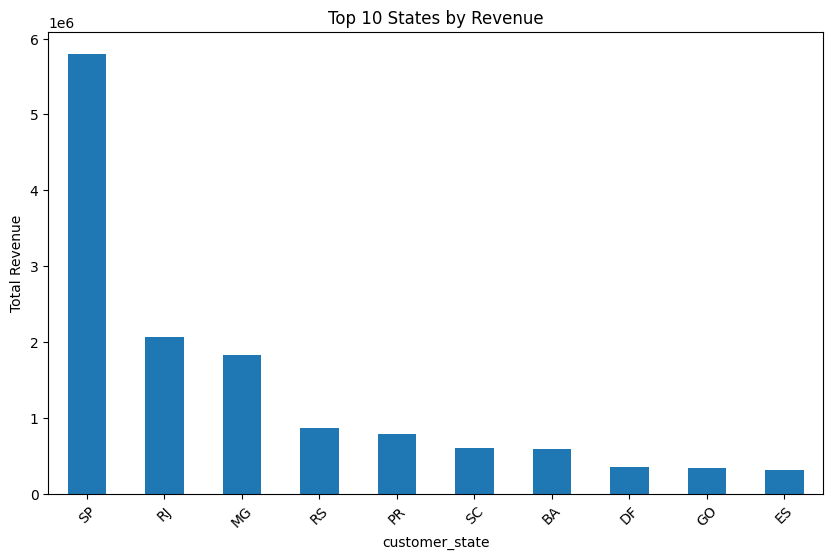

In [ ]:
top_states = state_revenue.head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind='bar')
plt.title('Top 10 States by Revenue')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

## 🔥 **INSIGHT STRATEGIS**

🥇 1️⃣ **São Paulo (SP) Sangat Dominan**

SP **menyumbang**:

≈ 5.8 juta
≈ 37% dari total revenue (15.49 juta)

Ini sangat signifikan.

👉 **SP** sendirian menyumbang **lebih dari 1/3 total revenue nasional.**

🥈 2️⃣ **SP + RJ + MG**

Jika digabung:

SP + RJ + MG ≈ 5.8M + 2.06M + 1.8M
≈ 9.6 juta

Itu **berarti**:

**~62% revenue** berasal dari hanya **3 state.**

Ini menunjukkan **konsentrasi regional cukup tinggi.**

📍 3️⃣ **Konsentrasi di Wilayah Southeast Brazil**

SP, RJ, MG semuanya berada di wilayah Southeast.

**Artinya:**

* Revenue sangat terkonsentrasi di wilayah ekonomi kuat

* Penetrasi di wilayah lain masih rendah

* Potensi ekspansi geografis besar

📈 **ANALISIS GRAFIK**

Dari grafik terlihat:

* SP jauh lebih tinggi dari state lain

* Distribusi revenue tidak merata antar state

* Long tail effect pada state kecil

Ini menunjukkan:

**Marketplace sangat kuat di metropolitan region.**

🎯 **STRATEGIC BUSINESS IMPLICATION**

1️⃣ **Regional Risk**

Jika ekonomi SP terganggu → bisnis bisa terdampak signifikan.

2️⃣ **Growth Opportunity**

State dengan revenue rendah:

* BA

* GO

* ES

* DF

Berpotensi menjadi target ekspansi marketing.

3️⃣ **Logistik & Seller Strategy**

Karena revenue terpusat di SP:

* Warehouse strategy bisa dioptimalkan di SP

* Fast shipping region bisa difokuskan di Southeast

📌 **TAMBAHAN**

Analisis geografis menunjukkan bahwa revenue sangat terkonsentrasi di wilayah Southeast Brazil, dengan São Paulo menyumbang sekitar 37% total revenue. Hal ini menunjukkan dominasi pasar di wilayah metropolitan dan potensi ekspansi yang signifikan di wilayah lain yang kontribusinya masih relatif kecil.

# **PRODUCT CATEGORY PERFORMANCE ANALYSIS**

## **Revenue per Category**

In [ ]:
category_revenue = master_df.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=False)

category_revenue.head(10)

,revenue
product_category_name_english,
health_beauty,1417268.99
watches_gifts,1265552.91
...,...
auto,671019.97
garden_tools,568573.01


## **Revenue per Category**

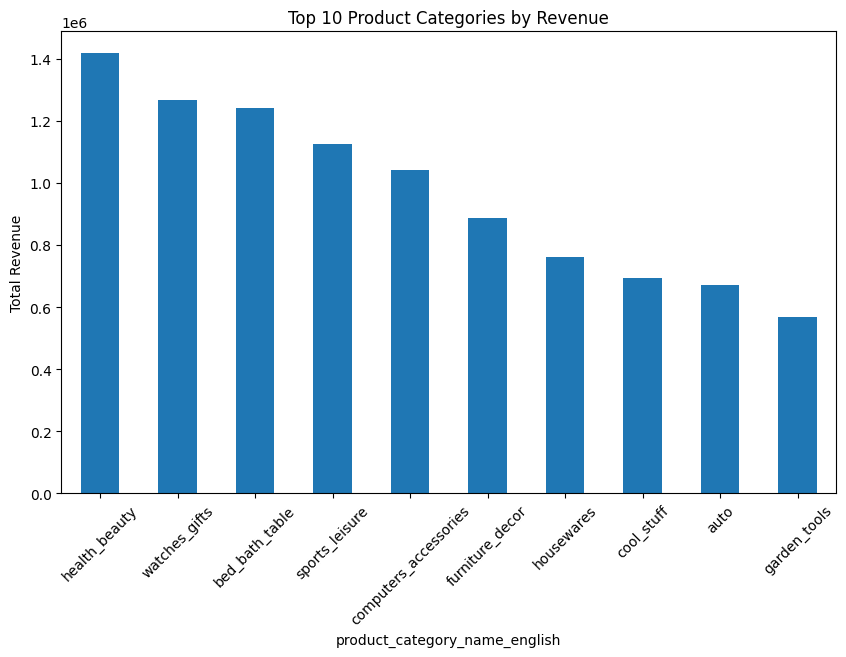

In [ ]:
top_categories = category_revenue.head(10)

plt.figure(figsize=(10,6))
top_categories.plot(kind='bar')
plt.title('Top 10 Product Categories by Revenue')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

## 🔥 **STRATEGIC ANALYSIS**

🥇 1️⃣ **Health & Beauty adalah kategori tertinggi**

Revenue ≈ 1.4 juta (~9% total revenue)

Ini menunjukkan:

* Produk personal care sangat kuat

* Repeat potential tinggi

* Consumable nature (bisa repeat order)

👉 Ini kandidat utama untuk **retention strategy.**

🥈 2️⃣ **Watches & Gifts juga sangat kuat**

Kategori ini:

* High perceived value

* Cocok untuk seasonal campaign

* Kemungkinan naik saat Black Friday

🛏 3️⃣ **Bed, Bath & Table stabil dan tinggi**

Ini kategori kebutuhan rumah tangga:

* Demand stabil

* Less seasonal

* Cocok untuk subscription model

📊 **Apakah Revenue Terkonsentrasi?**

Mari kita lihat total 3 kategori teratas:

1.41M + 1.26M + 1.24M ≈ 3.91M

Total revenue 15.49M

👉 Top 3 kategori menyumbang ≈ 25%

**Artinya:**

Revenue tidak terlalu terkonsentrasi pada satu kategori saja.

Marketplace ini cukup terdiversifikasi.

##🔎 **STRATEGIC INSIGHT**
1️⃣ **Diversifikasi Produk Sehat**

Tidak ada satu kategori dominan ekstrem.

Ini mengurangi risiko kategori tunggal.

2️⃣ Opportunity Cross-Selling

Karena kategori top bersifat lifestyle & household:

* Beauty + Fashion

* Bed/Bath + Furniture

* Sports + Accessories

3️⃣ **Margin Strategy Opportunity**

Kategori seperti:

* Watches_gifts

* Computers_accessories

Berpotensi margin lebih tinggi dibanding kebutuhan rumah tangga.

📌 **TAMBAHAN**

Analisis kategori produk menunjukkan bahwa revenue relatif terdiversifikasi tanpa dominasi ekstrem dari satu kategori. Tiga kategori teratas hanya menyumbang sekitar 25% dari total revenue, menunjukkan struktur marketplace yang cukup seimbang dan tidak bergantung pada satu lini produk tertentu.

# **SELLER PERFORMANCE ANALYSIS**

## **SELLER PERFORMANCE ANALYSIS**

In [ ]:
seller_revenue = master_df.groupby('seller_id')['revenue'].sum().sort_values(ascending=False)

seller_revenue.head(10)

,revenue
seller_id,
4869f7a5dfa277a7dca6462dcf3b52b2,247007.06
7c67e1448b00f6e969d365cea6b010ab,239645.07
...,...
7a67c85e85bb2ce8582c35f2203ad736,160908.92
955fee9216a65b617aa5c0531780ce60,156698.66


## **Pareto Seller**

In [ ]:
seller_rev = seller_revenue.reset_index()

seller_rev['cumulative_revenue'] = seller_rev['revenue'].cumsum()
seller_rev['cumulative_percentage'] = seller_rev['cumulative_revenue'] / seller_rev['revenue'].sum()

top_80_seller = seller_rev[seller_rev['cumulative_percentage'] <= 0.8]

percentage_seller = len(top_80_seller) / len(seller_rev) * 100

print("Percentage of sellers contributing 80% revenue:", round(percentage_seller,2), "%")

Percentage of sellers contributing 80% revenue: 18.52 %


## 📊 **SELLER PERFORMANCE ANALYSIS**

🎯 **Top Seller Revenue**

Top seller tertinggi:

≈ 247.007
≈ 239.645
≈ 160K – 150K range

Jika dibandingkan dengan total revenue 15.49 juta:

👉 **Top seller** hanya menyumbang **~1.6% dari total revenue.**

Ini sangat penting.

🔥 **teks tebal**PARETO SELLER RESULT

18.52% seller menyumbang 80% revenue

📈 **INTERPRETASI**
🎯 Ini Hampir Classic 80/20 Rule

Biasanya:

20% entity → 80% outcome

Di sini:

18.5% seller → 80% revenue

Artinya:

👉 Marketplace cukup seller-concentrated.

🔎 **BUSINESS IMPLICATION**

1️⃣ **Revenue Bergantung pada Seller Tertentu**

Jika 18% seller performa turun:

Revenue bisa terdampak besar.

2️⃣ **Seller Power Distribution**

Customer revenue relatif merata (48% → 80%)
Tapi seller revenue cukup terkonsentrasi (18% → 80%)

Ini berarti:

Marketplace customer-driven,
namun supply-side seller cukup terkonsentrasi.

3️⃣ **Strategic Risk**

Jika top sellers:

* Pindah platform

* Menurunkan kualitas

* Kehabisan stok

Marketplace bisa terdampak signifikan.

🎯 **STRATEGIC RECOMMENDATION**

🟢 **Retain Top Sellers**

* Priority onboarding

* Seller incentive

* Commission reduction for top tier

🟢 **Develop Mid-Tier Sellers**

* Training program

* Visibility boost

* Marketing support

🟢 **Reduce Concentration Risk**

* Recruit more sellers in high-performing categories

# **EXECUTIVE SUMMARY**

## **📌 Executive Summary**

Analisis menunjukkan bahwa marketplace memiliki pertumbuhan revenue signifikan sepanjang 2017 dan mencapai fase stabil pada 2018. Total revenue mencapai 15.49 juta dengan AOV sebesar 160.55.

Customer analysis menunjukkan repeat rate rendah (~3%), mengindikasikan peluang besar untuk meningkatkan retention strategy. RFM segmentation menunjukkan Loyal Customers dan Big Spenders menyumbang lebih dari 60% revenue.

Pareto analysis menunjukkan bahwa 48.74% customer menyumbang 80% revenue, mengindikasikan distribusi revenue yang relatif merata dan tidak terlalu bergantung pada segelintir high-value customer.

Namun dari sisi supply, 18.52% seller menyumbang 80% revenue, menunjukkan adanya konsentrasi performa pada seller tertentu yang berpotensi menjadi risiko bisnis.

Secara geografis, revenue sangat terkonsentrasi di wilayah Southeast Brazil, terutama São Paulo yang menyumbang sekitar 37% total revenue.

Kategori produk menunjukkan struktur marketplace yang terdiversifikasi tanpa dominasi ekstrem pada satu kategori tertentu.

In [ ]:
master_df.to_csv('main_data.csv', index=False)